# EDA and Model Validation


In [6]:
import sys
sys.path.append("..")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sentence_transformers import SentenceTransformer
plt.rcParams['figure.figsize']=(8,4)


## dataset building

In [7]:
# Loading datasets from data/ToS (Sentences, Labels) and building a only one dataset by join. It will be the dataset used for framework building.

def load_dataset(base_path='data/ToS'):
    sentences_path = os.path.join(base_path, 'Sentences')
    labels_path = os.path.join(base_path, 'Labels')
    rows = []
    for file in sorted(os.listdir(sentences_path)):
        if not file.endswith('.txt'):
            continue
        company = file.replace('.txt', '')
        with open(os.path.join(sentences_path, file), 'r', encoding='utf-8', errors='ignore') as f:
            sentences = f.read().splitlines()
        with open(os.path.join(labels_path, file), 'r', encoding='utf-8', errors='ignore') as f:
            labels = [int(x) for x in f.read().splitlines()]
        n = min(len(sentences), len(labels))
        for i in range(n):
            sent = sentences[i].strip()
            if sent:
                rows.append({'company': company, 'sentence_id': i, 'sentence': sent, 'label': labels[i]})
    return pd.DataFrame(rows)

df = load_dataset()
df.head(20)


,company,sentence_id,sentence,label
0,9gag,0,* accepting the terms of service,-1
1,9gag,1,"the purpose of this website , 9gag .",-1
2,9gag,2,"com -lrb- the `` site '' -rrb- , owned and ope...",-1
3,9gag,3,please read these terms of service -lrb- `` ag...,-1
4,9gag,4,"by using or accessing the services , you agree...",1
5,9gag,5,if you do not agree to all the terms and condi...,-1
6,9gag,6,the services are accessed by you -lrb- `` subs...,-1
7,9gag,7,subject to the terms and conditions of this ag...,-1
8,9gag,8,"services shall include , but not be limited to...",-1
9,9gag,9,"9gag , inc may change , suspend or discontinue...",1


## dataset overview


### Label balance

In [8]:
print('Rows:', len(df))
print('Companies:', df['company'].nunique())
print(df['label'].value_counts().sort_index())


Rows: 9414
Companies: 50
label
-1    8382
 1    1032
Name: count, dtype: int64


### Variability

In [9]:
df['n_words'] = df['sentence'].str.split().str.len()
df['n_chars'] = df['sentence'].str.len()
df[['n_words', 'n_chars']].describe()


,n_words,n_chars
count,9414.000000,9414.00000
mean,32.704376,182.84130
std,25.125387,141.90623
min,6.000000,13.00000
25%,17.000000,96.00000
50%,27.000000,148.00000
75%,40.000000,225.00000
max,441.000000,2653.00000


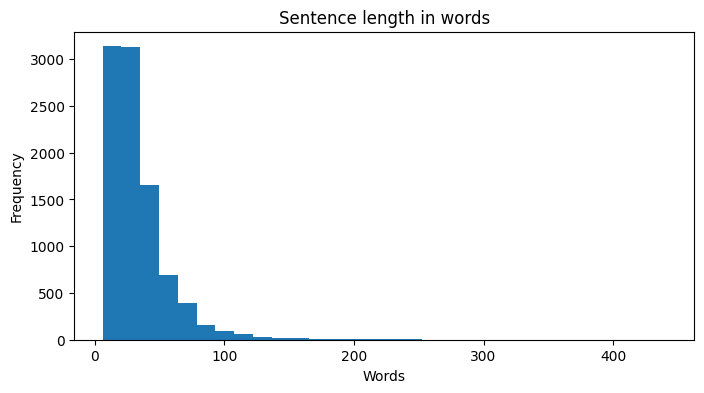

In [10]:
ax = df['n_words'].plot(kind='hist', bins=30)
ax.set_title('Sentence length in words')
ax.set_xlabel('Words')
plt.show()


Clause length varies significantly across the dataset, with an average of 32 words and some much longer sentences. This shows that the data contains clauses with very different sizes and structures. Based on this, sentence embeddings were chosen as the main text representation method, since they are more suitable for handling variable-length clauses while preserving semantic meaning.

### label distribuition (company level)

In [11]:
# Distribuição por empresa
distribution = (
    df.groupby(['company', 'label'])
      .size()
      .unstack(fill_value=0)
      .rename(columns={-1: 'fair', 1: 'unfair'})
)

# Total por empresa
distribution['total'] = distribution['fair'] + distribution['unfair']

# % dentro da empresa
distribution['fair_pct'] = distribution['fair'] / distribution['total'] * 100
distribution['unfair_pct'] = distribution['unfair'] / distribution['total'] * 100

# % da empresa no dataset
distribution['dataset_pct'] = distribution['total'] / len(df) * 100

# Ordenar por unfair
distribution = distribution.sort_values(by='unfair_pct', ascending=False)

print(distribution[['total', 'dataset_pct', 'unfair_pct']].round(2))

label            total  dataset_pct  unfair_pct
company                                        
Twitter             80         0.85       22.50
Atlas               60         0.64       21.67
TrueCaller          98         1.04       21.43
Supercell          141         1.50       20.57
Betterpoints_UK    113         1.20       20.35
Moves-app           75         0.80       17.33
YouTube            113         1.20       16.81
Crowdtangle         78         0.83       16.67
9gag               139         1.48       15.83
Skyscanner          83         0.88       15.66
Deliveroo          143         1.52       15.38
WhatsApp            98         1.04       15.31
Vivino             125         1.33       15.20
Instagram          158         1.68       15.19
Dropbox            121         1.29       14.88
Tinder             195         2.07       14.87
Google              93         0.99       13.98
Syncme             115         1.22       13.91
Duolingo           140         1.49     

Label distribution varies across companies, both in the number of clauses and the proportion of potentially unfair clauses. This indicates that different companies follow different patterns when writing their Terms of Service.

### Top companies by kpi unfair clause rate

In [12]:
company_stats = df.groupby('company').agg(sentences=('sentence', 'count'), unfair_rate=('label', lambda s: (s == 1).mean()))
company_stats.sort_values('unfair_rate', ascending=False).head(10)


,sentences,unfair_rate
company,,
Twitter,80,0.225000
Atlas,60,0.216667
TrueCaller,98,0.214286
Supercell,141,0.205674
Betterpoints_UK,113,0.203540
Moves-app,75,0.173333
YouTube,113,0.168142
Crowdtangle,78,0.166667
9gag,139,0.158273


Some companies present a higher proportion of potentially unfair clauses. For example, Twitter has an unfair rate of about 22%, meaning roughly 1 in 5 clauses may be considered unfair.

### clauses by company - pattern understanding

In [13]:


def show_company_breakdown(df, company, n=3):
    print(f"\n=== {company} ===")
    
    fair = df[(df['company'] == company) & (df['label'] == -1)]
    unfair = df[(df['company'] == company) & (df['label'] == 1)]
    
    print("\nFAIR examples:")
    for s in fair['sentence'].sample(min(n, len(fair)), random_state=42):
        print("-", s)
    
    print("\nUNFAIR examples:")
    for s in unfair['sentence'].sample(min(n, len(unfair)), random_state=42):
        print("-", s)

# exemplo
show_company_breakdown(df, "Tinder")


=== Tinder ===

FAIR examples:
- super likes and other virtual items .
- tinder will terminate the accounts of repeat infringers .
- create another account if we have already terminated your account , unless you have our permission .

UNFAIR examples:
- this agreement , and any dispute between you and the company , shall be governed by the laws of the state of texas without regard to principles of conflicts of law , provided that this arbitration agreement shall be governed by the federal arbitration act .
- tinder shall have no liability to you or any third party in the event that tinder exercises any such rights .
- if you initiate a chargeback or otherwise reverse a payment made with your payment method , tinder may terminate your account immediately in its sole discretion .


In [14]:
# exemplo
show_company_breakdown(df, "Twitter")


=== Twitter ===

FAIR examples:
- the services are available `` as-is ''
- no advice or information , whether oral or written , obtained from the twitter entities or through the services , will create any warranty or representation not expressly made herein .
- -lrb- if you live outside of the us -rrb-

UNFAIR examples:
- by using the services you agree to be bound by these terms .
- you understand that through your use of the services you consent to the collection and use -lrb- as set forth in the privacy policy -rrb- of this information , including the transfer of this information to the united states , ireland , and/or other countries for storage , processing and use by twitter and its affiliates .
- we may stop -lrb- permanently or temporarily -rrb- providing the services or any features within the services to you or to users generally .


In [15]:
# exemplo
show_company_breakdown(df, "Microsoft")


=== Microsoft ===

FAIR examples:
- microsoft reserves the right to charge you for such services -lrb- at the normal rate -rrb- in the event that microsoft determines -lrb- in its reasonable discretion -rrb- that you are breaching the terms and conditions of the offer .
- suspension or cancellation of the services for non-payment could result in a loss of access to and use of your account and its content .
- the privacy statement also describes how microsoft uses your content , which is your communications with others ; postings or feedback submitted by you to microsoft via the services ; and the files , photos , documents , audio , digital works , and videos that you upload , store or share through the services -lrb- `` your content '' -rrb- .

UNFAIR examples:
- by downloading or using the application , or attempting to do any of these , you accept these terms .
- to the maximum extent permitted by law , these limitations and exclusions apply to anything or any claims related to the

Comparing different companies shows that clause patterns depend on the type of service and business model. For example, Tinder presents an unfair rate of around 14.9% over 2.07% of the dataset, while Microsoft shows a lower unfair rate of about 5.5% despite representing a larger portion of the dataset (5.82%). Twitter, with an unfair rate of approximately 22.5%, has one of the highest proportions of potentially unfair clauses.

This indicates that the proportion of potentially unfair clauses is not directly related to the size of the company in the dataset, but rather to how Terms of Service are structured. As a result, potentially unfair clauses can appear in different forms depending on the company context, which adds complexity to the classification task.

In [16]:
# key words

from collections import Counter

unfair_words = Counter(" ".join(df[df['label']==1]['sentence']).lower().split()).most_common(10)
fair_words = Counter(" ".join(df[df['label']==-1]['sentence']).lower().split()).most_common(10)

print("Unfair words:", unfair_words)
print("Fair words:", fair_words)

Unfair words: [(',', 3081), ('or', 2136), ('the', 2081), ('of', 1565), ('to', 1532), ('any', 1116), ('.', 1003), ('and', 935), ('you', 848), ('in', 696)]
Fair words: [(',', 16448), ('the', 11465), ('or', 8578), ('to', 7823), ('.', 7418), ('and', 7036), ('of', 6789), ('you', 6313), ('any', 4299), ('in', 3455)]


## Semantic search evaluation

In [17]:
from src.search_engine import SearchEngine
from src.embedder import Embedder

engine = SearchEngine()
embedder = Embedder()

def search(query, top_k=5):
    vector = embedder.encode([query])[0]
    return engine.search(vector, top_k)

### 

The semantic search was evaluated qualitatively using manually defined queries and inspection of the retrieved results. The system was able to return clauses with similar meaning across different companies and formulations, indicating that the embeddings capture semantic relationships beyond exact word matching.

Additionally, a simple quantitative check was performed by measuring the proportion of potentially unfair clauses among the top retrieved results. This provided an indication of how often the search retrieves risk-related clauses.

The similarity score was also used in the user interface to help interpret the results, where lower scores indicate higher similarity between the query and the retrieved clause.

However, no formal evaluation metrics such as precision@k or recall were applied, as the dataset does not include query-level relevance annotations. Therefore, the evaluation remains primarily qualitative. A possible extension would be to define queries and relevant clauses to enable a more formal evaluation of retrieval performance.

In [35]:
query = "we may terminate your account without notice"
results = search(query, top_k=10)

for r in results:
    print(f"{r['score']:.3f} | label={r['label']} | {r['sentence']}")

    ### resultados mais relevantes ;  score menor?

0.463 | label=1 | we may terminate your account if you repeatedly infringe the intellectual property rights of others . 
0.495 | label=1 | we can deactivate your account at any time . 
0.499 | label=-1 | we will endeavor to notify you by email or at the next time you attempt to access your account after any such deactivation , termination or suspension . 
0.544 | label=-1 | if you wish to terminate your account , you may do so by following the instructions on the site . 
0.547 | label=-1 | create another account if we have already terminated your account , unless you have our permission . 
0.556 | label=-1 | you may terminate your account at our service at any time by uninstalling the service and ceasing to use the service . 
0.556 | label=-1 | account deletion : you may delete your account at any time . 
0.580 | label=1 | we may terminate your access to and use of the services , at our sole discretion , at any time and without notice to you . 
0.583 | label=1 | if we feel that your be

The results show a consistent ranking based on the similarity score, where lower scores correspond to clauses that are semantically closer to the query. The retrieved clauses capture similar meanings expressed with different wording, such as account termination, deactivation, or service suspension, indicating that the embedding model generalizes well across variations in language.

Additionally, many of the top results are labeled as potentially unfair, which aligns with the intent of the query. However, some fair clauses are also retrieved, reflecting the fact that semantic similarity does not necessarily imply unfairness. This highlights the importance of combining semantic search with classification when assessing clause risk.

In [20]:
queries = [
    "we may terminate your account without notice",
    "we can change terms at any time",
    "you may close your account anytime",
    "we are not responsible for any damages"
]

for q in queries:
    print(f"\n=== QUERY: {q} ===")
    results = search(q)

    for r in results[:5]:
        print(f"- ({r['company']}) [{r['label']}] {r['sentence']}")


=== QUERY: we may terminate your account without notice ===
- (Masquerade) [1] we may terminate your account if you repeatedly infringe the intellectual property rights of others . 
- (Deliveroo) [1] we can deactivate your account at any time . 
- (Endomondo) [-1] we will endeavor to notify you by email or at the next time you attempt to access your account after any such deactivation , termination or suspension . 
- (Vivino) [-1] if you wish to terminate your account , you may do so by following the instructions on the site . 
- (Tinder) [-1] create another account if we have already terminated your account , unless you have our permission . 

=== QUERY: we can change terms at any time ===
- (PokemonGo) [1] we may modify these terms at any time . 
- (Skyscanner) [1] we may amend these terms at any time at our discretion . 
- (WhatsApp) [1] we may amend or update these terms . 
- (Microsoft) [1] we may change these terms at any time , and we 'll tell you when we do . 
- (Masquerade) [

A qualitative evaluation of the semantic search shows that the system retrieves clauses with similar meaning across different companies and formulations. 

For example, a query about account termination returns clauses related to deactivation, suspension, and account closure, even when different wording is used. Similarly, a query about changing terms retrieves clauses such as “we may modify”, “we may amend”, and “we may update these terms”, all expressing the same concept.

In addition, queries related to user rights (e.g., “you may close your account anytime”) return consistent results across companies, indicating strong semantic alignment. Queries about liability also return clauses related to responsibility limitations, such as “we are not liable” or “we are not responsible”.

These results show that the embedding-based approach captures semantic relationships beyond exact word matching and generalizes well across different writing styles and companies.

In [21]:
def evaluate_query(query, top_k=5):
    results = search(query)[:top_k]
    
    unfair_count = sum(1 for r in results if r['label'] == 1)
    ratio = unfair_count / top_k
    
    print(f"\nQuery: {query}")
    print(f"Unfair results in top {top_k}: {unfair_count}/{top_k} ({ratio:.2f})")
    
    for r in results:
        label = "UNFAIR" if r['label'] == 1 else "FAIR"
        print(f"- [{label}] {r['sentence']}")

# exemplo
evaluate_query("we may terminate your account without notice")


Query: we may terminate your account without notice
Unfair results in top 5: 2/5 (0.40)
- [UNFAIR] we may terminate your account if you repeatedly infringe the intellectual property rights of others . 
- [UNFAIR] we can deactivate your account at any time . 
- [FAIR] we will endeavor to notify you by email or at the next time you attempt to access your account after any such deactivation , termination or suspension . 
- [FAIR] if you wish to terminate your account , you may do so by following the instructions on the site . 
- [FAIR] create another account if we have already terminated your account , unless you have our permission . 


## Train/test split and validation


In [22]:
X_text = df['sentence'].tolist()
y = df['label'].values
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)
print('Train size:', len(X_train_text))
print('Test size:', len(X_test_text))


Train size: 7531
Test size: 1883


In [23]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_train = embedder.encode(X_train_text, show_progress_bar=True)
X_test = embedder.encode(X_test_text, show_progress_bar=True)


Batches: 100%|██████████| 59/59 [00:01<00:00, 31.93it/s]


In [24]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:,1]


/Users/ana.m.magalhaes/Desktop/ana/TOS_project/tos_simple_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ana.m.magalhaes/Desktop/ana/TOS_project/tos_simple_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ana.m.magalhaes/Desktop/ana/TOS_project/tos_simple_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ana.m.magalhaes/Desktop/ana/TOS_project/tos_simple_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ana.m.magalhaes/Desktop/

In [25]:
print(classification_report(y_test, pred, digits=3))


              precision    recall  f1-score   support

          -1      0.918     0.993     0.954      1677
           1      0.838     0.277     0.416       206

    accuracy                          0.915      1883
   macro avg      0.878     0.635     0.685      1883
weighted avg      0.909     0.915     0.895      1883



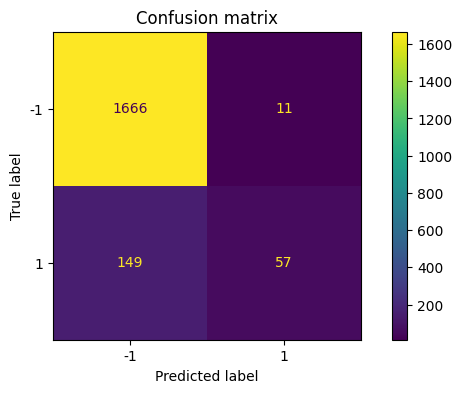

In [26]:
cm = confusion_matrix(y_test, pred, labels=[-1, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 1])
disp.plot()
plt.title('Confusion matrix')
plt.show()


The confusion matrix shows that the model performs very well in identifying fair clauses, with a high number of true negatives (1666) and very few false positives (11). However, it struggles to correctly identify potentially unfair clauses, as indicated by the relatively high number of false negatives (149) compared to true positives (57).

This behavior suggests that the model is biased towards predicting the majority class, which is expected given the class imbalance in the dataset. As a result, the model is conservative and may fail to detect some unfair clauses, which is a critical limitation for this use case.

## Example predictions


In [27]:
examples = ['we may terminate your account at any time without notice', 'you may close your account at any time', 'we may change these terms at any time without notice', 'we are not liable for damages arising from your use of the service']
vecs = embedder.encode(examples)
preds = clf.predict(vecs)
probs = clf.predict_proba(vecs)[:,1]
pd.DataFrame({'text': examples, 'predicted_label': preds, 'prob_unfair': probs})


,text,predicted_label,prob_unfair
0,we may terminate your account at any time with...,1,0.575813
1,you may close your account at any time,-1,0.224303
2,we may change these terms at any time without ...,1,0.924144
3,we are not liable for damages arising from you...,1,0.517937


Example predictions show that the model captures meaningful risk patterns in the clauses. Expressions such as "without notice" and "change terms at any time" receive higher probabilities of being unfair, while more neutral clauses such as "you may close your account" are classified as fair with lower risk scores.

The probability outputs also reflect different levels of confidence, with some clauses receiving intermediate scores around 0.5, indicating uncertainty. This behavior is consistent with the confusion matrix results, where the model struggles to confidently identify all unfair clauses.

Some examples where the model produced incorrect or uncertain predictions are shown below. These were collected during testing and help illustrate cases where the model struggles, especially with subtle or borderline clauses.

These observations suggest that future improvements could focus on better handling these edge cases, for example by refining the training data or adjusting the model.

In [ ]:

examples = [
    "you may close your account at any time",
    "we may terminate your account at any time without notice",
    "we are not liable for any claim relating to any content , goods and/or services of third parties ."
]

for e in examples:
    print(e)

you may close your account at any time
we may terminate your account at any time without notice
we are not liable for any claim relating to any content , goods and/or services of third parties .


### conclusions

------------

--------

-----------------------

## final tests and checks

### loader.py

In [29]:

from src.loader import load_dataset
df = load_dataset()
print(df.head())
print(df.shape)
print(df["label"].value_counts())

  company                                           sentence  label
0   Viber  thanks for sending us good vibes by using the ...     -1
1   Viber  you may be surprised , but we will refer to al...     -1
2   Viber  the terms of use -lrb- or , the `` terms '' -r...     -1
3   Viber  the language of the terms will seem legal -lrb...     -1
4   Viber  when you use our services , in addition to enj...      1
(9414, 3)
label
-1    8382
 1    1032
Name: count, dtype: int64


### embeddings.py 

In [30]:
from src.embedder import Embedder
e = Embedder()
# check qualquer para ver se é 384 dim
vec = e.encode(["we may terminate your account"])
print(type(vec), len(vec), len(vec[0]))

<class 'numpy.ndarray'> 1 384


### build_index.py 

In [31]:
ls models

classifier.pkl  faiss.index     metadata.pkl


### search_engine.py 

In [32]:
from src.search_engine import SearchEngine
from src.embedder import Embedder

engine = SearchEngine()
embedder = Embedder()
# precisa trazer similares
q = embedder.encode(["we may terminate your account without notice"])[0]
results = engine.search(q, top_k=3)
print(results)

[{'sentence': 'we may terminate your account if you repeatedly infringe the intellectual property rights of others . ', 'company': 'Masquerade', 'label': 1, 'score': 0.46333521604537964}, {'sentence': 'we can deactivate your account at any time . ', 'company': 'Deliveroo', 'label': 1, 'score': 0.49462854862213135}, {'sentence': 'we will endeavor to notify you by email or at the next time you attempt to access your account after any such deactivation , termination or suspension . ', 'company': 'Endomondo', 'label': -1, 'score': 0.49920654296875}]


### train_classifier.py 

In [33]:
from src.classifier import ClauseClassifier
from src.embedder import Embedder

clf = ClauseClassifier()
embedder = Embedder()
vec = embedder.encode(["we may terminate your account at any time without notice"])[0]
print(clf.predict(vec))

{'label': 1, 'probability': 0.6551131327763569}


### main.py

- http://127.0.0.1:8000/health
- http://127.0.0.1:8000/docs              #deve abrir os endpoints

### stremlit_app.py

In [34]:
import os
API_URL = os.getenv("API_URL", "http://127.0.0.1:8000")

### check requirements.txt 

- fastapi
- uvicorn
- pandas
- numpy
- scikit-learn
- faiss-cpu
- sentence-transformers
- streamlit
- requests
- matplotlib

### Dockerfile

API em 8000

### Dockerfile_ui

UI em 8501

### docker-compose.yml

Serviços api e ui

### Check .dockerignore

- venv
- __pycache__
- *.pyc
- .git
- .gitignore

### check README

- o que a ferramenta faz
- arquitetura
- dataset
- design decisions
- limitations
- user guide
- como rodar local
- como rodar UI
- como rodar Docker

### coerência 

- streamlit_app.py usa os mesmos campos que a API retorna
- /search recebe query e top_k
- /classify recebe text
- SearchEngine.search() recebe vetor
- notebook usa Embedder + SearchEngine, não texto direto no engine
- Dockerfile copia models/
- README bate com os comandos reais

------

# FINAL CHECKLIST 

- loader funciona SIM 
- embeddings funcionam SIM 
- índice foi gerado SIM 
- classificador foi treinado SIM 
- /health responde SIM 
- /search responde SIM 
- /classify responde SIM 
- Streamlit abre SIM 
- notebook abre SIM 
- builds Docker funcionam SIM 
- README está atualizado SIM 

- GERAR O RELATÓRIO FINAL
- GERAR O MANUAL USUÁRIO